In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-20-_jpg.rf.bf2a3a5eb89acb02de58bccd79a5515d.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-106-_jpg.rf.fcaa85ea3b822953e2102ef3384532ca.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-179-_jpg.rf.68dd8ede9901c18aae3126f54d145f67.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-194-_jpg.rf.8b53e2b52af411b816676dba1dfcb506.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-77-_jpg.rf.b23fe7ede31f873c273d25a39e8f353b.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-188-_jpg.rf.6bb797d7fe59491a218703437a9c3cbb.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-62-_jpg.rf.1cc00a591d6942f1dedd901c136a335f.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-91-_jpg.rf.3e007170e11f413d1676978c95ba9ac3.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-196-_jpg.rf.920892

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/dataset-vgg/dataset_vgg/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 2496 files belonging to 3 classes.


In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/dataset-vgg/dataset_vgg/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 624 files belonging to 3 classes.


In [5]:
cnn = tf.keras.models.Sequential()

In [6]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))



In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))



In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


In [10]:

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [11]:
cnn.add(tf.keras.layers.Dropout(0.25))



In [12]:
cnn.add(tf.keras.layers.Flatten())



In [13]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))



In [14]:
cnn.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting


In [15]:
#Output Layer
cnn.add(tf.keras.layers.Dense(units=3,activation='softmax'))

In [16]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,790,227 (29.72 MB)

 Trainable params: 7,790,227 (29.72 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


I0000 00:00:1724960444.928285      78 service.cc:145] XLA service 0x7a9ddc006af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1724960444.928337      78 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1724960444.928350      78 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 2/78 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.3594 - loss: 2.1672  

I0000 00:00:1724960456.434778      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.4431 - loss: 1.3258 - val_accuracy: 0.5321 - val_loss: 0.9492
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6187 - loss: 0.8136 - val_accuracy: 0.5208 - val_loss: 0.9690
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.6495 - loss: 0.7699 - val_accuracy: 0.6138 - val_loss: 0.8326
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.6905 - loss: 0.6980 - val_accuracy: 0.5946 - val_loss: 0.8615
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.7476 - loss: 0.5848 - val_accuracy: 0.6026 - val_loss: 0.8225
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.7709 - loss: 0.5200 - val_accuracy: 0.6074 - val_loss: 0.9777
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8351 - loss: 0.4245 - val_accuracy: 0.6154 - val_loss: 1.0271
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8797 - loss: 0.3296 - val_accuracy: 0.6522 - val_loss: 1

In [18]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9498 - loss: 0.1401
Training accuracy: 0.9619390964508057


In [19]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6704 - loss: 1.2319
Validation accuracy: 0.6794871687889099


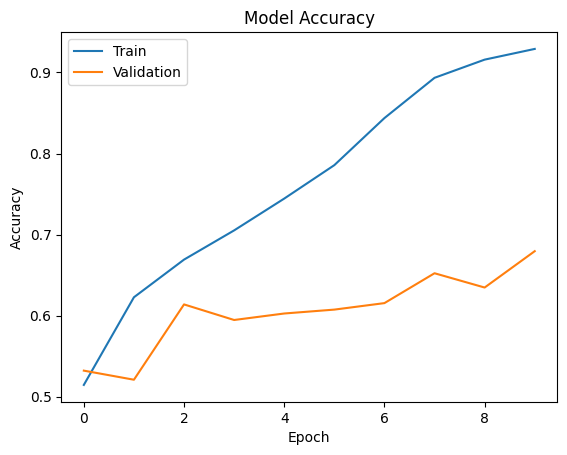

In [20]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()



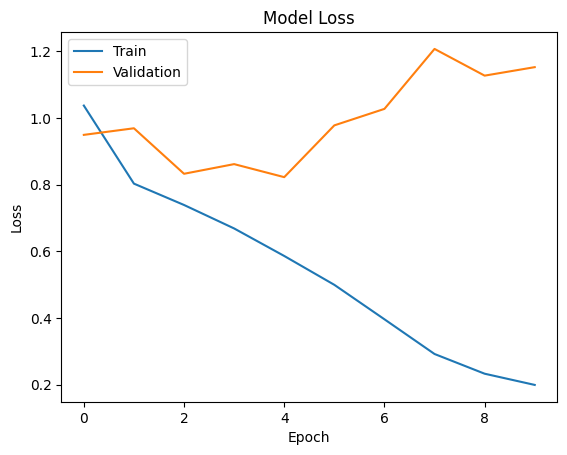

In [21]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(training_history.history  ['loss'])
plt.plot(training_history.history ['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
